# Alzheimer MRI Classification using ResNet50
Train / Validation split from train folder, augmentation, evaluation and prediction.

In [16]:
# ===============================
# 1 Import Libraries
# ===============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight # For dynamic class weights

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.10.0


In [17]:
# ===============================
# 2 GPU Configuration
# ===============================

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPUs:", gpus)


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
import os
import shutil
import random
from pathlib import Path

def split_dataset(input_dir, output_dir, split_ratio=(0.7, 0.15, 0.15), seed=42):
    """
    Splits a dataset into train, val, and test sets.
    """
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    
    # Ensure ratios sum up to 1
    train_ratio, val_ratio, test_ratio = split_ratio
    assert round(train_ratio + val_ratio + test_ratio, 5) == 1.0, "Ratios must sum to 1.0"
    
    # The folders you specified
    classes = ['down', 'normal']
    splits = ['train', 'val', 'test']
    
    # 1. Create the output directory structure
    for split in splits:
        for cls in classes:
            (output_path / split / cls).mkdir(parents=True, exist_ok=True)
            
    # Set seed for reproducibility
    random.seed(seed)
    
    # 2. Distribute files for each class
    for cls in classes:
        cls_dir = input_path / cls
        
        if not cls_dir.exists():
            print(f"Warning: Directory '{cls_dir}' does not exist. Skipping.")
            continue
            
        # Get all files in the class directory (ignoring hidden files/folders)
        files = [f for f in cls_dir.iterdir() if f.is_file() and not f.name.startswith('.')]
        random.shuffle(files)
        
        # Calculate split indices
        total_files = len(files)
        train_idx = int(total_files * train_ratio)
        val_idx = train_idx + int(total_files * val_ratio)
        
        # Slice the list of files
        train_files = files[:train_idx]
        val_files = files[train_idx:val_idx]
        test_files = files[val_idx:]
        
        # Helper function to copy files
        def copy_files(file_list, split_name):
            for f in file_list:
                dest = output_path / split_name / cls / f.name
                shutil.copy2(f, dest) # copy2 preserves metadata
                
        # Execute the copy
        copy_files(train_files, 'train')
        copy_files(val_files, 'val')
        copy_files(test_files, 'test')
        
        print(f"Class '{cls}': Copied {len(train_files)} train, {len(val_files)} val, {len(test_files)} test.")

# --- Run the Script ---
# This assumes your original folder is named "dataset" 
# and you want the split folders inside a new folder called "split_dataset"
split_dataset(
    input_dir='dataset', 
    output_dir='split_dataset', 
    split_ratio=(0.70, 0.15, 0.15) # 70% Train, 15% Validation, 15% Test
)

Class 'down': Copied 1050 train, 225 val, 225 test.
Class 'normal': Copied 1049 train, 224 val, 226 test.


In [19]:
# ===============================
# 3 Paths and Parameters
# ===============================

TRAIN_DIR = "split_dataset/train"
TEST_DIR = "split_dataset/test"
VAL_DIR   = "split_dataset/val"

IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

CLASSES = [
    'down', 'normal'

]


In [20]:
# ===============================
# 4 Load Train Dataset
# ===============================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    class_names=CLASSES, # Remember to keep this from our previous fix!
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 2099 files belonging to 2 classes.


In [21]:
# ===============================
# 5 Validation Dataset
# ===============================

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    class_names=CLASSES,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 449 files belonging to 2 classes.


In [22]:
# ===============================
# 6 Test Dataset
# ===============================

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    class_names=CLASSES,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # Crucial: Never shuffle the test set so your confusion matrix lines up
)

Found 451 files belonging to 2 classes.


In [23]:
# ===============================
# 7 Data Augmentation
# ===============================

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.1),
])

def augment(images, labels):
    images = data_augmentation(images)
    return images, labels

train_dataset = train_dataset.map(augment)


In [24]:
# ===============================
# 8 ResNet Preprocessing
# ===============================

def preprocess(images, labels):
    images = preprocess_input(images)
    return images, labels

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)


In [25]:
# ===============================
# 9 Prefetch for performance
# ===============================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)


In [28]:
# ===============================
# 10 Build ResNet Model
# ===============================
from tensorflow.keras import regularizers

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False 

model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(2, activation="softmax")
])

ImportError: `load_weights` requires h5py package when loading weights from HDF5. Try installing h5py.

In [37]:
# ===============================
# 11 Compile Model
# ===============================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="acc"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_2   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_4 (Dense)             (None, 256)               524544    
                                                                 
 batch_normalization_2 (Batc  (None, 256)              1024      
 hNormalization)                                                 
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_5 (Dense)             (None, 4)                

In [38]:
# ===============================
# 12 Training
# ===============================


# Dynamically compute class weights
y_train = np.concatenate([np.argmax(y.numpy(), axis=-1) for x, y in train_dataset])
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), weights))

# CRITICAL FIX: Cap the maximum weight so the model doesn't over-predict the rarest class
MAX_WEIGHT_CAP = 5.0 
class_weights = {k: min(v, MAX_WEIGHT_CAP) for k, v in class_weights.items()}

print(f"Capped Class Weights: {class_weights}")

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8, 
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.3, 
    patience=3, 
    min_lr=1e-7
)

# Fit the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)


Capped Class Weights: {0: 0.49404499338332597, 1: 0.7249190938511327, 2: 1.792, 3: 5.0}
Epoch 1/100
140/140 [==============================] - 32s 193ms/step - loss: 5.3236 - acc: 0.3685 - auc: 0.6264 - val_loss: 4.7640 - val_acc: 0.4646 - val_auc: 0.7255 - lr: 1.0000e-04
Epoch 2/100
140/140 [==============================] - 28s 196ms/step - loss: 4.3518 - acc: 0.4496 - auc: 0.7007 - val_loss: 4.0327 - val_acc: 0.5562 - val_auc: 0.8002 - lr: 1.0000e-04
Epoch 3/100
140/140 [==============================] - 31s 216ms/step - loss: 3.7397 - acc: 0.4871 - auc: 0.7404 - val_loss: 3.6985 - val_acc: 0.5333 - val_auc: 0.7778 - lr: 1.0000e-04
Epoch 4/100
140/140 [==============================] - 32s 227ms/step - loss: 3.3595 - acc: 0.5127 - auc: 0.7624 - val_loss: 3.0887 - val_acc: 0.6448 - val_auc: 0.8889 - lr: 1.0000e-04
Epoch 5/100
140/140 [==============================] - 33s 230ms/step - loss: 3.0306 - acc: 0.5493 - auc: 0.7920 - val_loss: 3.0541 - val_acc: 0.6260 - val_auc: 0.8406 - lr

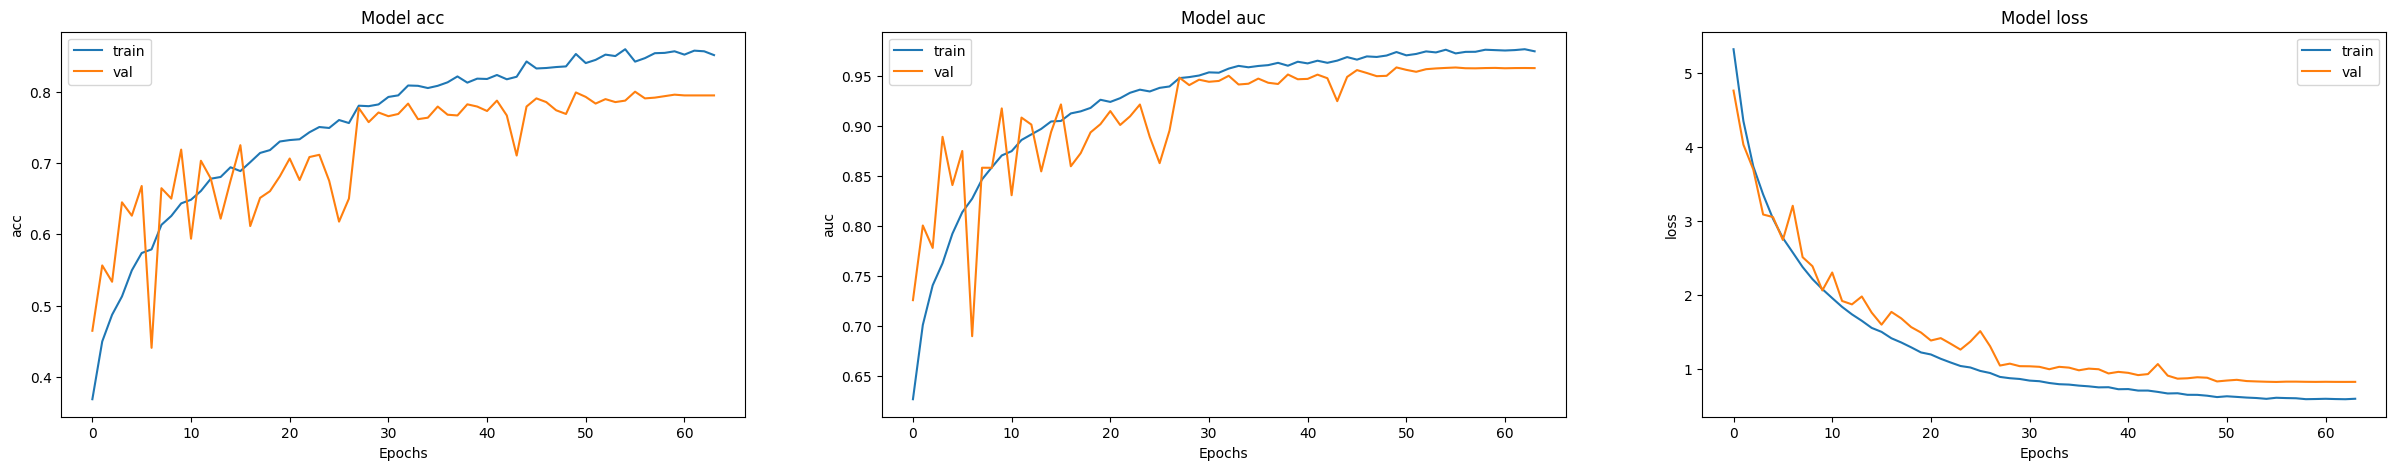

In [39]:
# ===============================
# 13 Plot Training Metrics
# ===============================

fig, ax = plt.subplots(1, 3, figsize = (30, 5))
ax = ax.ravel()

for i, metric in enumerate(["acc", "auc", "loss"]):
    ax[i].plot(history.history[metric])
    ax[i].plot(history.history["val_" + metric])
    ax[i].set_title("Model {}".format(metric))
    ax[i].set_xlabel("Epochs")
    ax[i].set_ylabel(metric)
    ax[i].legend(["train", "val"])

plt.show()


In [40]:
# ===============================
# 14 Evaluate on Test Set
# ===============================

test_scores = model.evaluate(test_dataset)

print('Testing Accuracy: %.2f%%' % (test_scores[1] * 100))


30/30 [==============================] - 4s 123ms/step - loss: 0.9207 - acc: 0.7448 - auc: 0.9399
Testing Accuracy: 74.48%


In [41]:
# ===============================
# 15 Predictions
# ===============================

y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())


1/1 [==============================] - 0s 26ms/step


In [42]:
# ===============================
# 16 Classification Report
# ===============================

print(classification_report(y_true, y_pred, target_names=CLASSES))


                  precision    recall  f1-score   support

     NonDemented       0.82      0.76      0.79       467
VeryMildDemented       0.72      0.70      0.71       358
    MildDemented       0.60      0.81      0.69       129
ModerateDemented       1.00      1.00      1.00         6

        accuracy                           0.74       960
       macro avg       0.78      0.82      0.80       960
    weighted avg       0.75      0.74      0.75       960



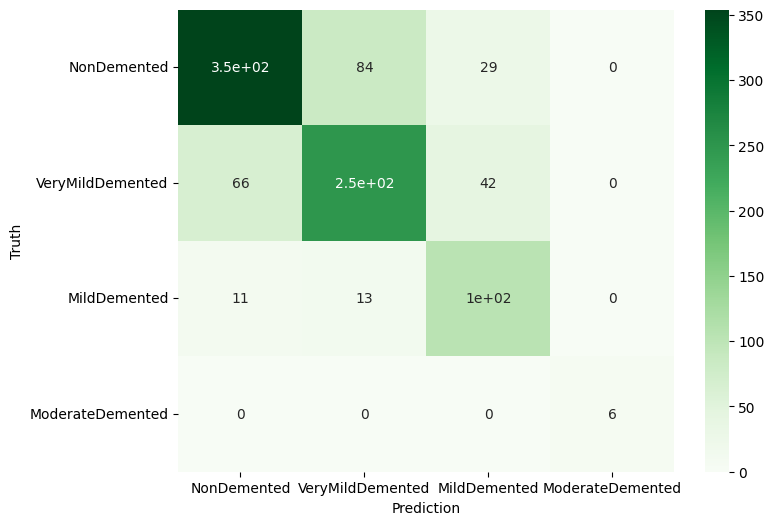

In [43]:
# ===============================
# 17 Confusion Matrix
# ===============================

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Greens",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Prediction")
plt.ylabel("Truth")

plt.show()


In [44]:
# ===============================
# 18 Save Model
# ===============================

model.save("alzheimer_resnet_model.keras")
print("Model saved.")


Model saved.
